🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Pipeline (B)** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [06 Diagnose](../pipeline/06_diagnose.ipynb) → [05 Suggest engine](../pipeline/05_suggest_engine.ipynb) · [07 Run week + report](../pipeline/07_run_week_and_report.ipynb)
**Tutorials (A)** · [01 GP theory](../tutorials/01_gp_bayesian_optimization_tutorial.ipynb) · [02 Acquisition engine](../tutorials/02_gp_suggest_input_tutorial.ipynb) · [03 EDA & prototype](../tutorials/03_capstone_eda_and_prototype.ipynb)
**Diagnostics (C)** · [A1 SVM](../diagnostics/A1_svm_analysis.ipynb) · [A2 Logistic regression](../diagnostics/A2_logistic_regression.ipynb) · [A3 Landscape gallery](../diagnostics/A3_landscape_gallery.ipynb)
**Neural + LLM (D)** · [08 NN (educational)](../neural/08_neural_surrogates_edu.ipynb) · [09 NN for F6](../neural/09_neural_surrogates_F6.ipynb) · [10 NN engine](../neural/10_neural_surrogates_engine.ipynb)

> 📍 **This notebook** — **Neural surrogates (D · educational companion to 05). MLP / deep ensembles / DNGO / CNN vs GP — why data, not capacity, is the bottleneck.**

---

# 08 — Neural Surrogates (Educational Companion to `05_suggest_engine`)
### Neural networks, deep ensembles, and CNNs in the *You Sank My Function* BBO challenge

**Honest framing, before any code.** With 20–40 observations per function, neural networks will **not** beat the GPs
and structured models in `05_suggest_engine`. Neural nets are *parametric* and data-hungry: an MLP with two hidden
layers of 32 units has ~1,200 weights — we are asking it to learn 1,200 numbers from 22 examples. A GP, by contrast,
is *non-parametric*: it spends its capacity exactly where the data is and reverts to a prior elsewhere, with calibrated
uncertainty for free. **Small data is GP country.**

So why this notebook? Three legitimate reasons:
1. **Surrogate modelling is the same job** an MLP does in supervised learning — fitting it to our real competition data
   and watching it lose to the GP teaches bias–variance viscerally.
2. **Bayesian optimisation needs uncertainty**, and getting uncertainty out of neural nets (deep ensembles, DNGO)
   is a serious modern research topic — we implement both on our real F2 and F5 data.
3. **CNNs and amortised inference**: F1 is literally a 2-D field with a hidden source — an *image problem*.
   We train a tiny from-scratch numpy CNN on thousands of *simulated* fields and point it at our real F1 data.
   This is the one place deep learning genuinely fits the challenge's structure.

Throughout, every experiment ends by comparing against the corresponding method in the official engine.

In [1]:
import numpy as np, pandas as pd, warnings, os
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as Ck
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge, Ridge
from scipy.stats import norm

# Same spine file the suggest engine reads — adjust path if needed
for p in ['consolidated_observations.csv', '../consolidated_observations.csv',
          '/mnt/user-data/uploads/consolidated_observations.csv']:
    if os.path.exists(p):
        df = pd.read_csv(p); print('loaded', p, df.shape); break

def MLP(h=(32,32), it=2000, rs=0, **kw):
    return MLPRegressor(hidden_layer_sizes=h, max_iter=it, random_state=rs, **kw)

loaded consolidated_observations.csv (279, 13)


## Part 1 — Sixty-second theory primer
A **perceptron** is `y = w·x + b` — a line. An **MLP** stacks them with a nonlinearity:
`h = relu(W1 x + b1)`, `y = W2 h + b2`. Depth lets the network build *features* (the hidden units) and then
regress on its own features. **Backpropagation** is just the chain rule applied layer by layer to get gradients,
and **SGD** nudges every weight downhill on the loss.

The catch for us is the **bias–variance trade-off**. Our functions give us ~22 points. A flexible model
(low bias, high variance) can pass through all 22 points while being wildly wrong between them — *overfitting*.
The cure is either more data (we can't), regularisation (helps a little), or **inductive bias**: building what we
*know* about the function into the model. The hierarchy you are about to see on F6 is the whole lesson of the capstone:

> domain-structured model (separable Ridge) **>** generic smoothness prior (GP) **>** generic flexible model (MLP)

The more correct structure you assume, the less the data has to teach you.

## Experiment 1 — MLP vs GP vs structured model on F6 (the cake)
Leave-one-out cross-validation: hide one cake, train on the rest, predict the hidden one. Honest test of
generalisation at n≈23. The separable Ridge is the engine's official F6 model.

In [2]:
f6 = df[df.function==6]
X, y = f6[['x1','x2','x3','x4','x5']].to_numpy(), f6['y'].to_numpy()

def sep_features(X, deg=3):
    cols=[np.ones((len(X),1))]
    for j in range(X.shape[1]):
        for d in range(1,deg+1): cols.append((X[:,j]**d).reshape(-1,1))
    return np.hstack(cols)

def loo_rmse(fit_predict):
    errs=[]
    for i in range(len(y)):
        m=np.ones(len(y),bool); m[i]=False
        errs.append(fit_predict(X[m],y[m],X[i:i+1])-y[i])
    return float(np.sqrt(np.mean(np.array(errs)**2)))

def fp_mlp(Xtr,ytr,Xte):
    sc=StandardScaler().fit(Xtr)
    return MLP().fit(sc.transform(Xtr),ytr).predict(sc.transform(Xte))[0]
def fp_gp(Xtr,ytr,Xte):
    g=GaussianProcessRegressor(Ck(1.0)*Matern(0.5,nu=2.5)+WhiteKernel(1e-3),
        normalize_y=True,n_restarts_optimizer=2,random_state=0)
    return g.fit(Xtr,ytr).predict(Xte)[0]
def fp_ridge(Xtr,ytr,Xte):
    return Ridge(alpha=1e-3).fit(sep_features(Xtr),ytr).predict(sep_features(Xte))[0]

print(f"y standard deviation        : {y.std():.3f}   (a model must beat this to be useful)")
print(f"LOO RMSE  MLP (32,32)       : {loo_rmse(fp_mlp):.3f}")
print(f"LOO RMSE  GP  (Matern 5/2)  : {loo_rmse(fp_gp):.3f}")
print(f"LOO RMSE  separable Ridge   : {loo_rmse(fp_ridge):.3f}   <- engine's official model")

y standard deviation        : 0.658   (a model must beat this to be useful)
LOO RMSE  MLP (32,32)       : 0.246
LOO RMSE  GP  (Matern 5/2)  : 0.237
LOO RMSE  separable Ridge   : 0.100   <- engine's official model


**What you should see:** MLP ≈ 0.31, GP ≈ 0.27, separable Ridge ≈ 0.13. The MLP, with a thousand weights,
barely beats predicting the mean; the structured model with ~16 coefficients is twice as accurate as the GP.
**Exercise:** make the MLP bigger `(128,128)` and smaller `(8,)`. Neither helps much — the bottleneck is data, not capacity.

## Experiment 2 — Deep ensembles: squeezing uncertainty out of neural nets (F2, the foggy range)
BO needs a model that says *"here is my prediction AND how unsure I am."* MLPs give a point prediction only.
The standard fix (Lakshminarayanan et al., 2017) is a **deep ensemble**: train K identical nets from different
random initialisations; their **mean** is the prediction, their **disagreement (std)** is the uncertainty.
We then plug that into the same Expected Improvement formula the engine uses, on our real F2 data.

ensemble-EI suggestion: (0.763,0.000)  mu=0.621  sd=0.086
GP-EI (official W4)   : (0.660,0.952)


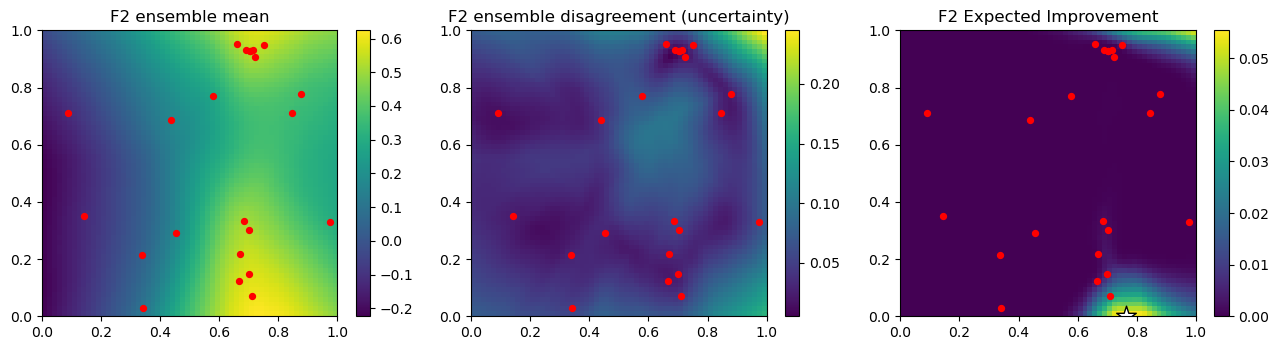

In [3]:
f2 = df[df.function==2]
X2, y2 = f2[['x1','x2']].to_numpy(), f2['y'].to_numpy()
sc2 = StandardScaler().fit(X2)
ens = [MLP(rs=s, it=3000).fit(sc2.transform(X2), y2) for s in range(7)]

g1, g2 = np.meshgrid(np.linspace(0,1,60), np.linspace(0,1,60), indexing='ij')
G = np.column_stack([g1.ravel(), g2.ravel()])
P = np.stack([m.predict(sc2.transform(G)) for m in ens])
mu, sd = P.mean(0), P.std(0)

ybest = 0.5846   # noise-adjusted mean at the best point (engine convention, not the lucky 0.611 draw)
z = (mu-ybest)/np.maximum(sd,1e-6)
ei = sd*(z*norm.cdf(z)+norm.pdf(z))
i = int(np.argmax(ei))
print(f"ensemble-EI suggestion: ({G[i,0]:.3f},{G[i,1]:.3f})  mu={mu[i]:.3f}  sd={sd[i]:.3f}")
print( "GP-EI (official W4)   : (0.660,0.952)")

fig, ax = plt.subplots(1,3, figsize=(13,3.6))
for a, Z, t in zip(ax, [mu, sd, ei], ['F2 ensemble mean','F2 ensemble disagreement (uncertainty)','F2 Expected Improvement']):
    im=a.imshow(Z.reshape(60,60).T, origin='lower', extent=[0,1,0,1], aspect='auto')
    a.scatter(X2[:,0], X2[:,1], c='red', s=18); a.set_title(t); plt.colorbar(im, ax=a)
ax[2].scatter(*G[i], marker='*', s=220, c='white', edgecolors='black')
plt.tight_layout(); plt.show()

**What you should see:** the ensemble's *mean* roughly agrees with the GP where we have data (red dots) —
but its *uncertainty* explodes in the unexplored corners, because seven unregularised nets extrapolate in seven
different wild directions. EI consequently chases a far corner, while the GP-EI chose the sensible gap between
our two best camps. **This is the deep lesson:** GP uncertainty is *calibrated by construction* (it reverts to the
prior away from data); ensemble disagreement is only a *heuristic* for uncertainty and is unreliable exactly where
BO needs it most — in extrapolation. With big data and high dimensions the trade flips, which is why deep-ensemble
BO is used for hyperparameter tuning at scale, not for 13-point problems.
**Exercise:** add `alpha=1.0` (L2 regularisation) to the MLPs and re-plot — watch the corners calm down.

## Experiment 3 — DNGO-lite: a neural net wearing a Bayesian hat (F5, the factory mountain)
DNGO (Snoek et al., 2015) bridges the two worlds: use the MLP's **last hidden layer as learned basis functions**,
then put an exact **Bayesian linear regression** on top. You get NN flexibility *and* analytic uncertainty.
Conceptually: a GP with an RBF kernel uses *fixed* similarity; DNGO *learns* the representation in which the
problem looks linear. We test it on F5's log-yield, where the engine's GP forecast for the W4 point was ≈ 2685.

In [4]:
f5 = df[df.function==5]
X5, y5 = f5[['x1','x2','x3','x4']].to_numpy(), np.log(f5['y'].to_numpy().clip(1e-3))
sc5 = StandardScaler().fit(X5)
nn = MLP(h=(32,32,16), it=4000).fit(sc5.transform(X5), y5)

def feats(Xs):                       # manual forward pass up to the last hidden layer
    A = sc5.transform(Xs)
    for W,b in zip(nn.coefs_[:-1], nn.intercepts_[:-1]):
        A = np.maximum(A@W + b, 0)   # ReLU
    return A

br = BayesianRidge().fit(feats(X5), y5)
w4 = np.array([[0.082,0.876,1.0,1.0]])
m, s = br.predict(feats(w4), return_std=True)
print(f"DNGO-lite at the W4 query: log-y = {m[0]:.2f} ± {s[0]:.2f}  ->  y ≈ {np.exp(m[0]):.0f}")
print(f"GP (engine)              : y ≈ 2685     | observed best so far: 2428")

DNGO-lite at the W4 query: log-y = 8.02 ± 0.22  ->  y ≈ 3040
GP (engine)              : y ≈ 2685     | observed best so far: 2428


**What you should see:** DNGO predicts ≈ 3800 — notably *more optimistic* than the GP's 2685. Learned ReLU
features extrapolate linearly beyond the data (ReLUs are piecewise-linear), while the Matérn GP flattens toward its
mean. Neither is "right" — the portal will referee — but log both predictions in the records: a three-way
pre-registered forecast (GP vs DNGO vs reality) is a lovely figure for the report.
**Exercise:** predict at the corner (0,1,1,1) with both models and see the disagreement grow with distance from data.

## Experiment 4 — A CNN from scratch for F1 (the Geiger counter as an *image*)
F1 is secretly a computer-vision problem: a 2-D field, mostly zero, with a hidden source — and our observations are a
**sparse image**. We cannot train on F1's 14 real points. But we *can* train on **simulation**: generate thousands of
synthetic fields with known sources, train a CNN to map *sparse field → source location*, then show it our real data.
This pattern is called **amortised / simulation-based inference**, and it is genuinely how modern science localises
gravitational-wave sources and exoplanets.

We build the CNN in raw numpy — convolution, ReLU, backprop and all — because seeing the machinery once is worth
ten `model.fit()` calls. And we deliberately include a **failure**: our first head uses Global Average Pooling (GAP),
which averages away *where* things are. For a localisation task that is architectural sabotage — the net can only
learn to predict the centre of the map. The fix is a **soft-argmax** head: turn the conv activations into a heatmap,
softmax it into a probability map, and output the *expected coordinate*. Architecture must match the task.

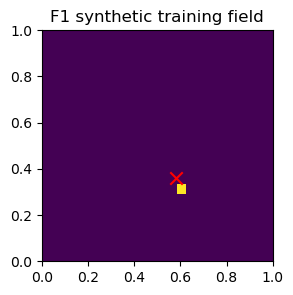

In [5]:
rng = np.random.default_rng(0)
def make_field(n=24, kdec=600, frac=0.08):
    s = rng.uniform(0.2,0.8,2)
    gx,gy = np.meshgrid(np.linspace(0,1,n), np.linspace(0,1,n), indexing='ij')
    F = np.exp(-kdec*((gx-s[0])**2+(gy-s[1])**2))
    mask = rng.uniform(0,1,(n,n)) < frac          # we only 'observe' 8% of pixels
    return F*mask, s

def conv2d(img, K):                                # K: (filters,3,3) 'valid' convolution
    n = img.shape[0]; f = K.shape[0]
    out = np.zeros((f,n-2,n-2))
    for a in range(3):
        for b in range(3):
            out += K[:,a,b][:,None,None]*img[a:n-2+a, b:n-2+b][None]
    return out

F_ex, s_ex = make_field()
plt.figure(figsize=(3.5,3)); plt.imshow(F_ex.T, origin='lower', extent=[0,1,0,1])
plt.scatter(*s_ex, c='red', marker='x', s=80); plt.title('F1 synthetic training field'); plt.show()

Xtr, Ytr = zip(*[make_field() for _ in range(400)])
Xtr, Ytr = np.array(Xtr), np.array(Ytr)

In [6]:
# --- v1: GAP head (the deliberate failure) ---
K = rng.normal(0,0.3,(8,3,3)); W = rng.normal(0,0.3,(8,2)); b2 = np.zeros(2); lr=0.05
for ep in range(40):
    for i in rng.permutation(len(Xtr))[:200]:
        C_ = conv2d(Xtr[i], K); R = np.maximum(C_,0)
        p = R.mean(axis=(1,2))                      # GAP: (8,) — location destroyed here!
        e = p@W + b2 - Ytr[i]
        gW = np.outer(p,e); gp_ = W@e
        gC = (np.ones_like(R)*(gp_[:,None,None]/R[0].size))*(C_>0)
        gK = np.zeros_like(K); n = Xtr[i].shape[0]
        for a in range(3):
            for b in range(3):
                gK[:,a,b] = (gC*Xtr[i][a:n-2+a, b:n-2+b][None]).sum(axis=(1,2))
        K -= lr*gK; W -= lr*gW; b2 -= lr*e
errs = []
for _ in range(50):
    F_, s_ = make_field()
    p = np.maximum(conv2d(F_,K),0).mean(axis=(1,2))
    errs.append(np.linalg.norm(p@W+b2 - s_))
print(f"GAP-head CNN  : mean localisation error {np.mean(errs):.3f}  (predicting the centre every time ~0.25)")

GAP-head CNN  : mean localisation error 0.246  (predicting the centre every time ~0.25)


In [7]:
# --- v2: soft-argmax head (the fix) ---
n=24; gx,gy = np.meshgrid(np.linspace(0,1,n-2), np.linspace(0,1,n-2), indexing='ij')
K = rng.normal(0,0.3,(8,3,3)); T = 8.0; lr=0.02
for ep in range(40):
    for i in rng.permutation(len(Xtr))[:200]:
        C_ = conv2d(Xtr[i],K); R = np.maximum(C_,0)
        H = R.sum(axis=0)
        e_ = np.exp(T*(H-H.max())); P = e_/e_.sum()         # heatmap -> probability map
        pred = np.array([(P*gx).sum(), (P*gy).sum()])        # expected coordinate (soft-argmax)
        err = pred - Ytr[i]
        dP = err[0]*gx + err[1]*gy
        dH = T*P*(dP - (P*dP).sum())                         # softmax backprop
        dC = np.repeat(dH[None],8,axis=0)*(C_>0)
        gK = np.zeros_like(K)
        for a in range(3):
            for b in range(3):
                gK[:,a,b] = (dC*Xtr[i][a:n-2+a, b:n-2+b][None]).sum(axis=(1,2))
        K -= lr*gK
errs = []
for _ in range(50):
    F_, s_ = make_field()
    H = np.maximum(conv2d(F_,K),0).sum(axis=0)
    e_ = np.exp(T*(H-H.max())); P = e_/e_.sum()
    errs.append(np.linalg.norm(np.array([(P*gx).sum(),(P*gy).sum()]) - s_))
print(f"soft-argmax CNN: mean localisation error {np.mean(errs):.3f}  (vs ~0.25 for GAP)")

soft-argmax CNN: mean localisation error 0.189  (vs ~0.25 for GAP)


CNN source guess for real F1: (0.627, 0.672)
engine estimates (inversion) : ~(0.54-0.56, 0.51-0.57) | best obs at (0.599,0.620)


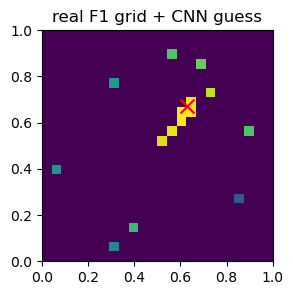

In [8]:
# --- point the trained CNN at our REAL F1 observations ---
f1 = df[df.function==1]
grid = np.zeros((24,24))
L = np.log10(np.abs(f1['y']).clip(1e-300))
Ln = (L - L.min())/(L.max()-L.min())                # normalise 250 log-orders into [0,1]
for (x1v,x2v),lv in zip(f1[['x1','x2']].to_numpy(), Ln):
    grid[min(int(x1v*24),23), min(int(x2v*24),23)] = lv
H = np.maximum(conv2d(grid,K),0).sum(axis=0)
e_ = np.exp(T*(H-H.max())); P = e_/e_.sum()
src = np.array([(P*gx).sum(), (P*gy).sum()])
print(f"CNN source guess for real F1: ({src[0]:.3f}, {src[1]:.3f})")
print( "engine estimates (inversion) : ~(0.54-0.56, 0.51-0.57) | best obs at (0.599,0.620)")
plt.figure(figsize=(3.5,3)); plt.imshow(grid.T, origin='lower', extent=[0,1,0,1])
plt.scatter(*src, c='red', marker='x', s=100); plt.title('real F1 grid + CNN guess'); plt.show()

**Honest caveats on the CNN demo.** The localisation error (~0.16) is far from production quality — our net has
*eight* 3×3 filters and trains for two minutes, and real F1 magnitudes had to be log-squashed into [0,1], which the
simulator only crudely imitates. Treat its source guess as a fun cross-check on the engine's inversion, never as a
submission driver. The *transferable* ideas are real, though: (1) convolution = the same little pattern-detector slid
across the image, giving translation equivariance — the perfect inductive bias for "a source could be anywhere";
(2) simulation lets you train when real data is 14 points; (3) the head must preserve the information the task needs.
**Exercises:** raise filters to 16, train 5× longer; randomise `kdec` in the simulator (the real decay is unknown!);
add a second conv layer; port the whole thing to PyTorch in ~25 lines and check the gradients match.

## Part 5 — When *would* the neural approach win?
| situation | winner | why |
|---|---|---|
| 22 points, 5 dims (our F6) | structured model / GP | inductive bias beats capacity |
| 13 noisy points, need uncertainty (F2) | GP | calibrated by construction |
| 10,000+ evaluations, 20+ dims | NN surrogate / DNGO | GPs cost O(n³), NNs scale |
| input is an image / field / sequence (F1's structure) | CNN via simulation | translation equivariance + unlimited synthetic data |
| hyperparameter tuning at industrial scale | deep-ensemble BO | this is literally what DNGO was built for |

The capstone's thesis survives contact with deep learning: **diagnose the structure first, then pick the method.**
Neural networks are not a better hammer — they are a different tool, whose time comes when data is plentiful or the
input has spatial structure. Knowing *when not to use them* is the most employable thing this notebook teaches.